# Customer Churn Prediction & Explainable Retention Engine
## Live Pakistan Internship - Week 1

## 1. Import Libraries

In [1]:
import pandas as pd

In [2]:
print(pd.__version__)

3.0.5


## 2. Load Dataset

In [3]:
df = pd.read_csv(r"D:\BSCS study\Projects\Live Pakistan\Week 1\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 3. Data Exploration

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 4. Data Cleaning

In [10]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [11]:
df = df.dropna()

In [12]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [13]:
df.shape

(7032, 21)

## 5. Data Visualization

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

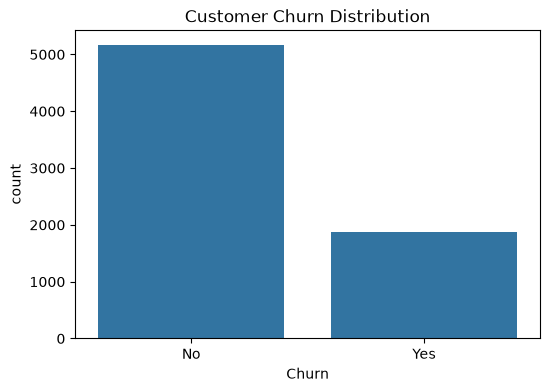

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 6. Feature Engineering

In [17]:
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"]

In [18]:
df[["TotalCharges", "tenure", "AvgMonthlySpend"]].head()

,TotalCharges,tenure,AvgMonthlySpend
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


In [19]:
df["CustomerLifetime"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["New", "Regular", "Loyal", "Veteran"]
)

In [20]:
df[["tenure", "CustomerLifetime"]].head(10)

,tenure,CustomerLifetime
0,1,New
1,34,Loyal
2,2,New
3,45,Loyal
4,2,New
5,8,New
6,22,Regular
7,10,New
8,28,Loyal
9,62,Veteran


In [21]:
average_charge = df["MonthlyCharges"].mean()

df["HighValueCustomer"] = (
    df["MonthlyCharges"] > average_charge
).astype(int)

In [22]:
df[["MonthlyCharges", "HighValueCustomer"]].head(10)

,MonthlyCharges,HighValueCustomer
0,29.85,0
1,56.95,0
2,53.85,0
3,42.30,0
4,70.70,1
5,99.65,1
6,89.10,1
7,29.75,0
8,104.80,1
9,56.15,0


In [23]:
import sklearn
print(sklearn.__version__)

1.9.0


In [24]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    (df[service_columns] != "No")
    & (df[service_columns] != "No internet service")
    & (df[service_columns] != "No phone service")
).sum(axis=1)

In [25]:
df[["TotalServices"]].head(10)

,TotalServices
0,2
1,4
2,4
3,4
4,2
5,6
6,5
7,2
8,7
9,4


In [26]:
df["ChargePerService"] = df["MonthlyCharges"] / df["TotalServices"]

In [27]:
(df["TotalServices"] == 0).sum()

np.int64(0)

In [28]:
df["ChargePerService"] = df["MonthlyCharges"] / df["TotalServices"]

In [29]:
df[["MonthlyCharges", "TotalServices", "ChargePerService"]].head(10)

,MonthlyCharges,TotalServices,ChargePerService
0,29.85,2,14.925000
1,56.95,4,14.237500
2,53.85,4,13.462500
3,42.30,4,10.575000
4,70.70,2,35.350000
5,99.65,6,16.608333
6,89.10,5,17.820000
7,29.75,2,14.875000
8,104.80,7,14.971429
9,56.15,4,14.037500


In [30]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [31]:
print(X.shape)
print(y.shape)

(7032, 25)
(7032,)


## 7. Data Preprocessing

In [32]:
categorical_features = X.select_dtypes(include=["str", "category"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

In [33]:
print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'CustomerLifetime'],
      dtype='str')

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlySpend', 'HighValueCustomer', 'TotalServices',
       'ChargePerService'],
      dtype='str')


In [34]:
X = X.drop("customerID", axis=1)

In [35]:
categorical_features = X.select_dtypes(include=["str", "category"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

In [36]:
print(categorical_features)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'CustomerLifetime'],
      dtype='str')


## 8. Logistic Regression

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

- Train-Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 24)
(1407, 24)
(5625,)
(1407,)


In [41]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [42]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['gender','SeniorCitizen','Partner',...,'HighValueCustomer', 'TotalServices','ChargePerService']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

In [43]:
print(X_train.shape)
print(X_test.shape)

(5625, 24)
(1407, 24)


In [44]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [45]:
y_pred = logistic_pipeline.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7938877043354655


In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1033
         Yes       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



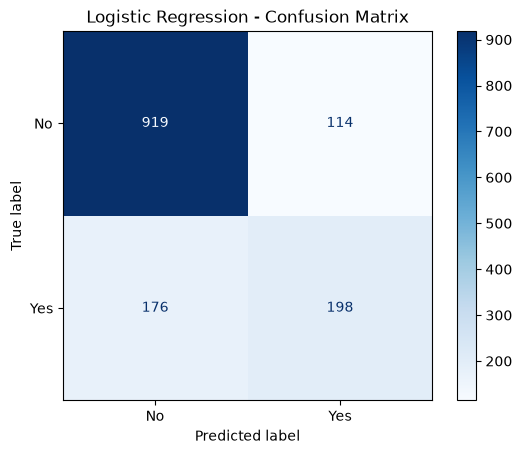

In [48]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 9. Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [51]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['gender','SeniorCitizen','Partner',...,'HighValueCustomer', 'TotalServices','ChargePerService']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

In [52]:
rf_pred = random_forest_pipeline.predict(X_test)

In [53]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7789623312011372


In [54]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

          No       0.83      0.89      0.85      1033
         Yes       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



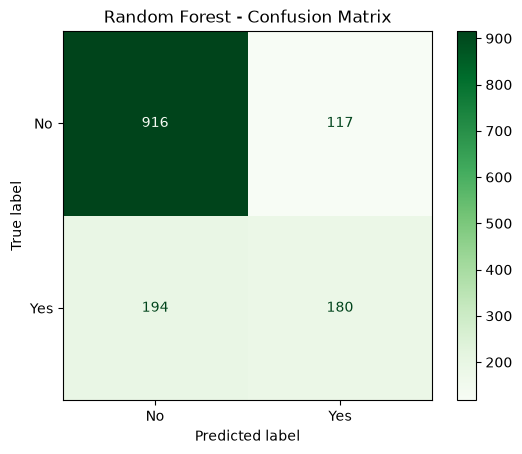

In [55]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

## 10. Gradient Boosting

In [56]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [57]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gradient_boosting_pipeline.fit(X_train, y_train)

gb_pred = gradient_boosting_pipeline.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.7945984363894811
              precision    recall  f1-score   support

          No       0.83      0.90      0.87      1033
         Yes       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



## 11. Support Vector Machine (SVM)

In [58]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(random_state=42))
])

svm_pipeline.fit(X_train, y_train)

svm_pred = svm_pipeline.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.7853589196872779
              precision    recall  f1-score   support

          No       0.82      0.91      0.86      1033
         Yes       0.64      0.43      0.52       374

    accuracy                           0.79      1407
   macro avg       0.73      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407



## 12. XGBoost

In [59]:
y_train_xgb = y_train.map({"No": 0, "Yes": 1})
y_test_xgb = y_test.map({"No": 0, "Yes": 1})

In [60]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train_xgb)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(y_test_xgb, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

print(classification_report(y_test_xgb, xgb_pred))

XGBoost Accuracy: 0.7825159914712153
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.54      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy,
        svm_accuracy,
        xgb_accuracy
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Gradient Boosting,0.794598
0,Logistic Regression,0.793888
3,SVM,0.785359
4,XGBoost,0.782516
1,Random Forest,0.778962


## 13. SMOTE (Handling Imbalanced Data)

In [62]:
from imblearn.over_sampling import SMOTE

In [63]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [64]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [65]:
print(X_train_processed.shape)
print(X_train_smote.shape)

print(y_train.value_counts())
print(y_train_smote.value_counts())

(5625, 53)
(8260, 53)
Churn
No     4130
Yes    1495
Name: count, dtype: int64
Churn
No     4130
Yes    4130
Name: count, dtype: int64


In [66]:
from sklearn.linear_model import LogisticRegression

logistic_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_smote.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [67]:
y_pred_smote = logistic_smote.predict(X_test_processed)

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.7341862117981521
              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1033
         Yes       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



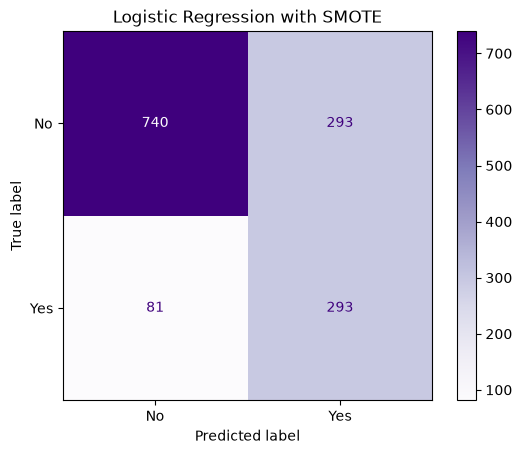

In [69]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote,
    cmap="Purples"
)

plt.title("Logistic Regression with SMOTE")
plt.show()

## 14. SHAP Explainability

In [70]:
import shap

C:\Users\Abu bakar computers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [71]:
import numpy as np
print(np.__version__)

2.3.3


In [72]:
import sys
print(sys.executable)

C:\Users\Abu bakar computers\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [73]:
import numpy as np
print(np.__version__)

2.3.3


In [74]:
import shap

Background dataset has 8260 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8260 when initializing the masker.


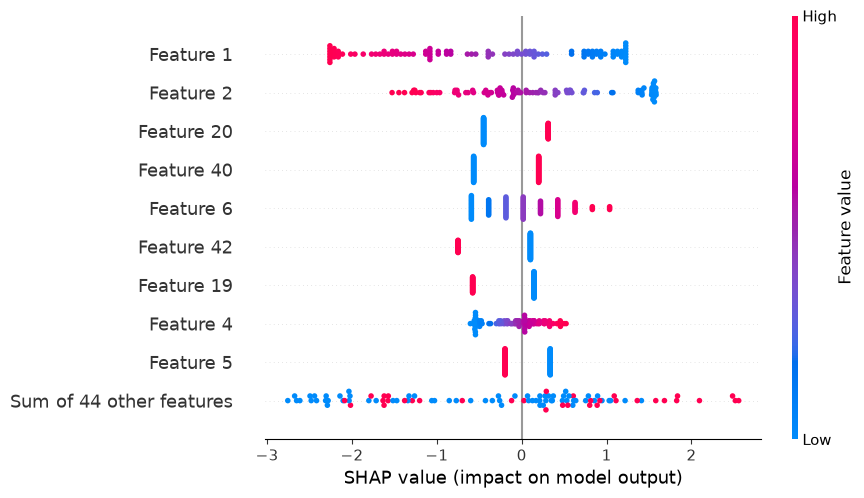

In [75]:
explainer = shap.Explainer(logistic_smote, X_train_smote)

shap_values = explainer(X_test_processed[:100])

shap.plots.beeswarm(shap_values)

In [76]:
import joblib

joblib.dump(gradient_boosting_pipeline, "best_churn_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [77]:
import os
os.listdir()

['.ipynb_checkpoints',
 'best_churn_model.pkl',
 'Customer_Churn_Prediction.ipynb']

In [78]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

## 15. Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "XGBoost",
        "Logistic + SMOTE"
    ],
    "Accuracy":[
        accuracy,
        rf_accuracy,
        gb_accuracy,
        svm_accuracy,
        xgb_accuracy,
        accuracy_score(y_test, y_pred_smote)
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

## 16. Save the Best Model

In [81]:
import joblib

joblib.dump(gradient_boosting_pipeline, "best_churn_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


## 17. Business Recommendations

- Gradient Boosting achieved the highest overall accuracy among the tested models.
- Applying SMOTE improved the model's ability to identify customers likely to churn.
- Customers with higher monthly charges and shorter tenure showed a greater likelihood of churn.
- Retention campaigns should focus on customers predicted as high-risk by the model.
- Machine learning can assist telecom companies in reducing customer churn and improving customer retention.

## Doing some Missing Work on the end 

In [83]:
import shap

In [84]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [85]:
feature_names = preprocessor.get_feature_names_out()

In [86]:
explainer = shap.LinearExplainer(
    logistic_smote,
    X_train_processed
)

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


In [87]:
shap_values = explainer(X_test_processed)

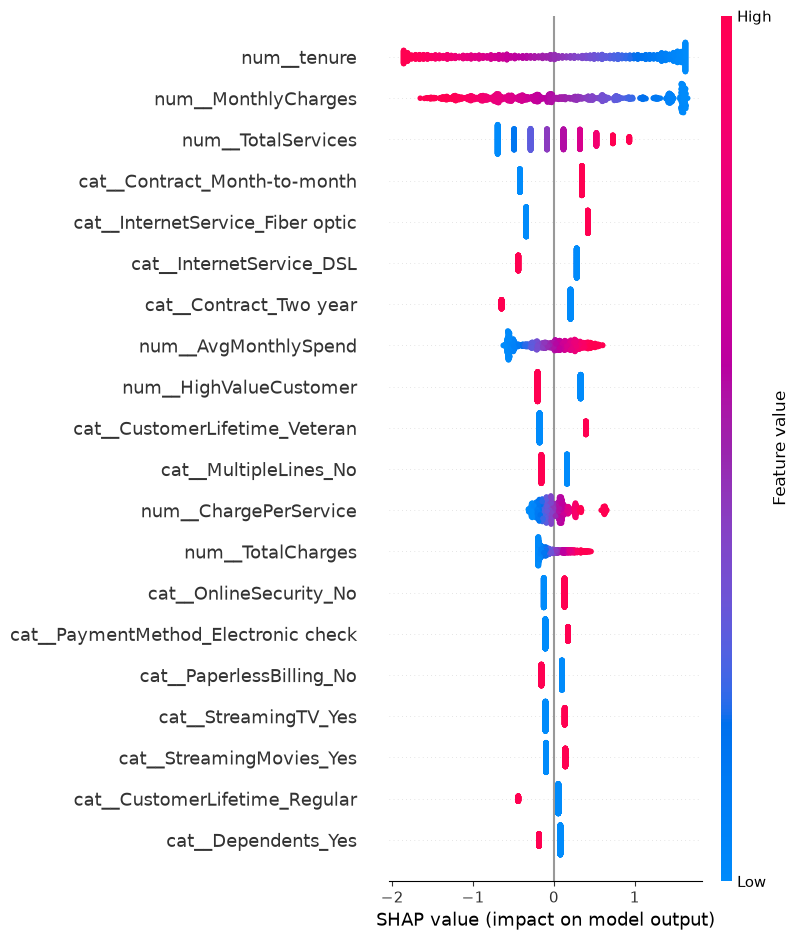

In [88]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

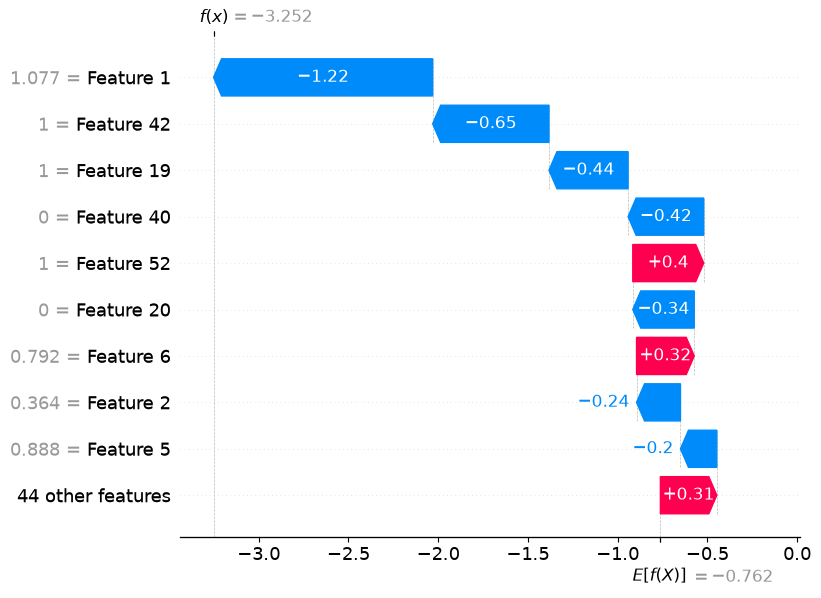

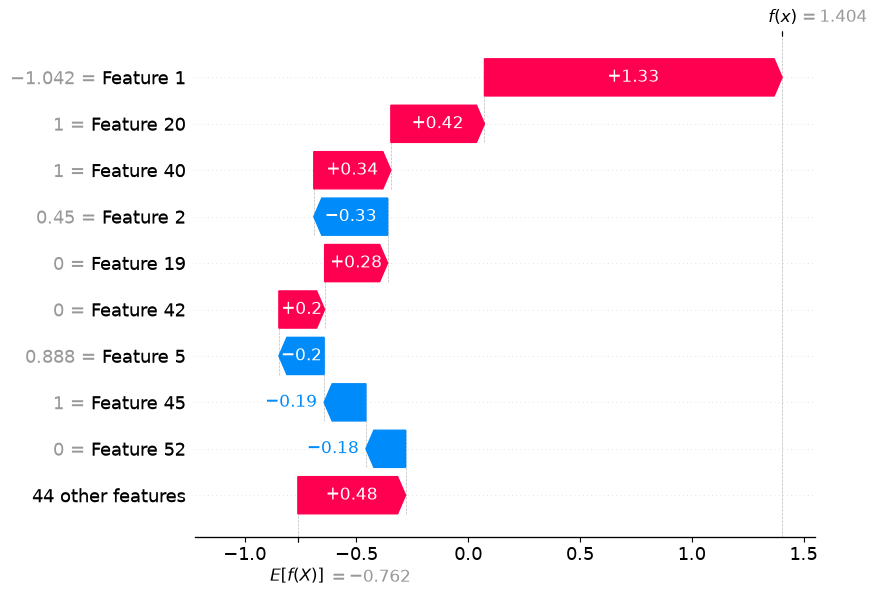

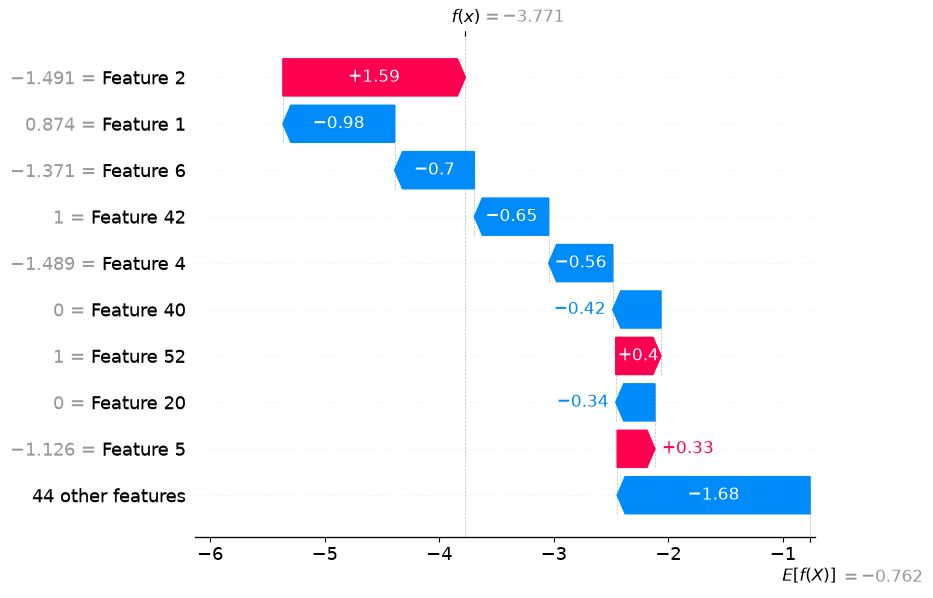

In [89]:
for i in [0, 1, 2]:
    shap.plots.waterfall(shap_values[i])

## Done SHAP for scrrenshots

## Now ROC-AUC and PR-AUC

In [90]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

In [91]:
y_prob = logistic_pipeline.predict_proba(X_test)[:,1]

In [92]:
y_test_binary = y_test.map({"No":0,"Yes":1})

In [93]:
roc = roc_auc_score(y_test_binary, y_prob)

pr = average_precision_score(
    y_test_binary,
    y_prob
)

print("ROC AUC:", roc)
print("PR AUC:", pr)

ROC AUC: 0.8355822043681504
PR AUC: 0.628230146529401


In [94]:
import joblib

joblib.dump(
    gradient_boosting_pipeline,
    "best_churn_model.pkl"
)

['best_churn_model.pkl']